### Loading data object

In [1]:
import math
import seaborn as sns
import numpy as np
import scanpy as sc
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from abc_atlas_access.abc_atlas_cache.abc_project_cache import AbcProjectCache

In [2]:
# Selecting the brain region
select_region = "Isocortex-1"

In [3]:
# Loading AnnData object
base_path = Path("/data/scRNA/ABCA/AIBS/AWS/expression_matrices/WMB-10Xv3/20230630/")
expr_path = base_path / f"processed/WMB-10Xv3-{select_region}-raw-wmeta-filtered.h5ad"
adata = sc.read_h5ad(expr_path)
adata

AnnData object with n_obs × n_vars = 227325 × 32285
    obs: 'cell_barcode', 'barcoded_cell_sample_label', 'library_label', 'feature_matrix_label', 'entity', 'brain_section_label', 'library_method', 'region_of_interest_acronym', 'donor_label', 'donor_genotype', 'donor_sex', 'dataset_label', 'x', 'y', 'cluster_alias', 'neurotransmitter', 'class', 'subclass', 'supertype', 'cluster', 'neurotransmitter_color', 'class_color', 'subclass_color', 'supertype_color', 'cluster_color', 'region_of_interest_order', 'region_of_interest_color'
    var: 'gene_symbol'

### Loading modules

In [4]:
# Loading Module Eigengenes dataframe
base_path = Path("/data/scRNA/ABCA/AIBS/AWS/expression_matrices/WMB-10Xv3/20230630/outputs")
modules_df = pd.read_csv(base_path / f"WMB-10Xv3-{select_region}-raw-mc-wgcna-modules.csv", index_col=0)
modules_df.head()

,gene_name,module,color,kME_Isocortex-M1,kME_Isocortex-M2,kME_Isocortex-M3,kME_Isocortex-M4,kME_grey,kME_Isocortex-M5,kME_Isocortex-M6,kME_Isocortex-M7,kME_Isocortex-M8,kME_Isocortex-M9
ENSMUSG00000015090,ENSMUSG00000015090,Isocortex-M1,yellow,0.645442,-0.082131,0.055263,0.123491,-0.087391,0.096088,0.129945,0.244009,0.606363,-0.205105
ENSMUSG00000031425,ENSMUSG00000031425,Isocortex-M1,yellow,0.919267,-0.107151,0.070567,0.095239,-0.112462,0.107643,0.243849,0.051845,0.041710,-0.244151
ENSMUSG00000115529,ENSMUSG00000115529,Isocortex-M1,yellow,0.290416,-0.025055,0.009020,0.027299,-0.029463,0.038628,0.236592,0.012456,0.003026,-0.099603
ENSMUSG00000029819,ENSMUSG00000029819,Isocortex-M2,turquoise,-0.003594,0.542115,0.002021,-0.003075,-0.085746,-0.004960,0.046668,0.012330,0.004241,-0.161405
ENSMUSG00000024610,ENSMUSG00000024610,Isocortex-M3,blue,0.006335,-0.033054,0.153545,0.040280,-0.027896,0.001917,-0.002614,0.018507,0.042056,-0.035275


In [5]:
module_names = {
    "Isocortex-M1": "Oligodendrocyte Myelination",
    "Isocortex-M2": "Neuronal Projection",
    "Isocortex-M3": "Immune Response",
    "Isocortex-M4": "Vascular Morphogenesis",
    "Isocortex-M5": "Developmental Signaling",
    "Isocortex-M6": "Neural Development",
    "Isocortex-M7": "Structural Morphogenesis",
    "Isocortex-M8": "Extracellular Matrix",
    "Isocortex-M9": "Axon Guidance",
}

In [6]:
# Rename the 'module' column in modules_df using module_names and save as a new dataframe
modules_df_renamed = modules_df.copy()
modules_df_renamed["module"] = modules_df_renamed["module"].map(module_names).fillna(modules_df_renamed["module"])
modules_df_renamed.head()

,gene_name,module,color,kME_Isocortex-M1,kME_Isocortex-M2,kME_Isocortex-M3,kME_Isocortex-M4,kME_grey,kME_Isocortex-M5,kME_Isocortex-M6,kME_Isocortex-M7,kME_Isocortex-M8,kME_Isocortex-M9
ENSMUSG00000015090,ENSMUSG00000015090,Oligodendrocyte Myelination,yellow,0.645442,-0.082131,0.055263,0.123491,-0.087391,0.096088,0.129945,0.244009,0.606363,-0.205105
ENSMUSG00000031425,ENSMUSG00000031425,Oligodendrocyte Myelination,yellow,0.919267,-0.107151,0.070567,0.095239,-0.112462,0.107643,0.243849,0.051845,0.041710,-0.244151
ENSMUSG00000115529,ENSMUSG00000115529,Oligodendrocyte Myelination,yellow,0.290416,-0.025055,0.009020,0.027299,-0.029463,0.038628,0.236592,0.012456,0.003026,-0.099603
ENSMUSG00000029819,ENSMUSG00000029819,Neuronal Projection,turquoise,-0.003594,0.542115,0.002021,-0.003075,-0.085746,-0.004960,0.046668,0.012330,0.004241,-0.161405
ENSMUSG00000024610,ENSMUSG00000024610,Immune Response,blue,0.006335,-0.033054,0.153545,0.040280,-0.027896,0.001917,-0.002614,0.018507,0.042056,-0.035275


### GO

In [8]:
from gprofiler import GProfiler

module_gene_dict = modules_df_renamed.groupby("module")["gene_name"].apply(list).to_dict()

gp = GProfiler(return_dataframe=True)
all_results = []

for module, genes in module_gene_dict.items():
    # gProfiler expects gene symbols or ENSEMBL IDs
    if len(genes) == 0:
        continue
    res = gp.profile(
        organism="mmusculus",
        query=genes,
        sources=['GO:BP'],
        user_threshold=0.05,
        significance_threshold_method='fdr'
    )
    if res.empty:
        continue
    res['module'] = module
    all_results.append(res)

results_df = pd.concat(all_results, ignore_index=True)

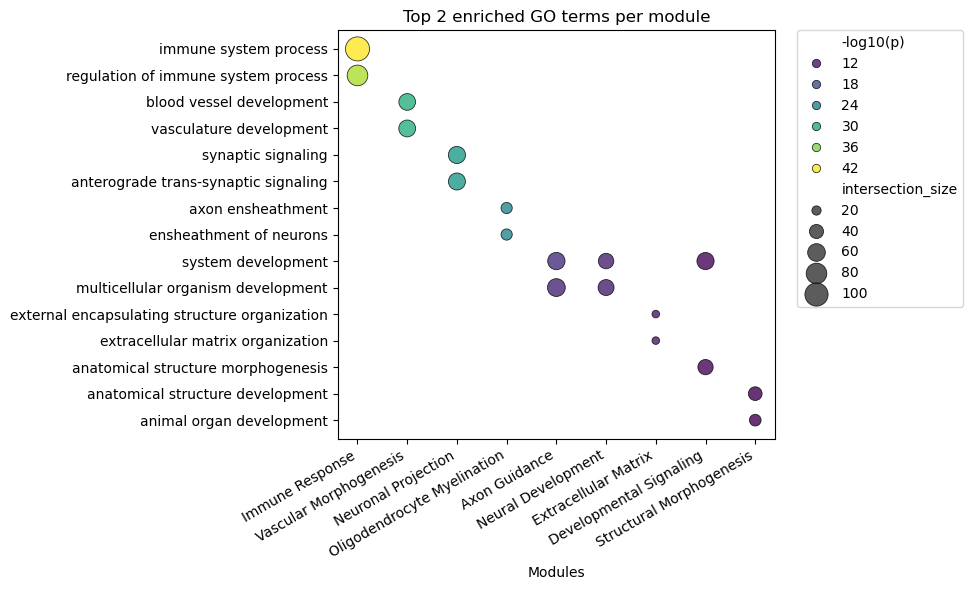

In [11]:
# ---------------------------------------------
# Parameters
# ---------------------------------------------
top_n = 2  # Top terms per cluster to include

# ---------------------------------------------
# Select top N enriched terms per cluster
# ---------------------------------------------
top_terms_df = (
    results_df
    .sort_values("p_value")
    .groupby("module")
    .head(top_n)
    .copy()
)

# Shorten term names for better plotting
top_terms_df["term_display"] = top_terms_df["name"].str.slice(0, 50)
top_terms_df["-log10(p)"] = -np.log10(top_terms_df["p_value"] + 1e-300)

# Optional: sort GO terms by frequency of appearance across clusters
term_order = (
    top_terms_df["term_display"]
    .value_counts()
    .index.tolist()
)

# ---------------------------------------------
# Create the Dot Plot
# ---------------------------------------------
plt.figure(figsize=(10, max(6, 0.4 * len(term_order))))
sns.scatterplot(
    data=top_terms_df,
    x="module",
    y="term_display",
    size="intersection_size",
    hue="-log10(p)",
    sizes=(30, 300),
    palette="viridis",
    edgecolor="black",
    alpha=0.8,
)

# Improve layout
plt.xticks(rotation=30, ha="right")
plt.ylabel("")
plt.xlabel("Modules")
plt.title(f"Top {top_n} enriched GO terms per module")

# Legends
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.tight_layout()
plt.savefig("figures/go_dotplot_Isocortx_CNA.svg")
plt.show()

### ME

In [7]:
from sklearn.decomposition import PCA

# Preprocess the data
sc.pp.normalize_total(adata, target_sum=1e4)  # Normalize counts per cell
sc.pp.log1p(adata)  # Log-transform the data
sc.pp.scale(adata)  # Scale the data

# Get unique modules and their gene lists
module_gene_dict = modules_df_renamed.groupby("module")["gene_name"].apply(list).to_dict()

# Store eigengenes in a DataFrame
eigengenes = pd.DataFrame(index=adata.obs_names)

for module, genes in module_gene_dict.items():
    # Filter genes present in adata
    genes_in_adata = [g for g in genes if g in adata.var_names]
    if len(genes_in_adata) < 2:
        continue  # Need at least 2 genes for PCA

    # Extract expression matrix for the module
    X = adata[:, genes_in_adata].X
    if not isinstance(X, np.ndarray):
        X = X.toarray()  # Convert sparse to dense if needed

    # Compute first principal component (eigengene)
    pca = PCA(n_components=1)
    eigengene = pca.fit_transform(X).flatten()
    eigengenes[module] = eigengene

eigengenes.head()

,Axon Guidance,Developmental Signaling,Extracellular Matrix,Immune Response,Neural Development,Neuronal Projection,Oligodendrocyte Myelination,Structural Morphogenesis,Vascular Morphogenesis
cell_label,,,,,,,,,
GCACTAAGTACAAGTA-399_B02,2.958812,-0.792568,0.528352,-1.038982,-0.592255,-0.758558,-1.228514,-0.238945,-1.165658
CAGAGCCGTCCTGGTG-399_A02,2.600224,-2.073552,-0.469465,-1.508286,-1.140003,-1.729488,-1.837307,-0.232849,-1.746566
CGCCATTCACGACAGA-403_A06,1.865214,-2.334886,-0.463058,-1.079665,-1.116549,0.336061,-2.047574,-0.688967,-1.371987
GGGTTTATCCGATCGG-399_B02,1.836583,-2.136351,-0.185522,-1.104986,-1.326958,-0.770627,-1.390435,-0.292726,-1.165365
GTGTGATCAGACAAAT-399_B02,3.115028,-1.995385,-0.557122,-0.647994,-1.145523,-2.775715,-1.306925,-0.239403,-1.162334


In [8]:
custom_module_order = [
 'Axon Guidance',
 'Neuronal Projection',
 'Developmental Signaling',
 'Neural Development',
 'Oligodendrocyte Myelination',
 'Extracellular Matrix',
 'Structural Morphogenesis',
 'Vascular Morphogenesis',
 'Immune Response'
 ]

### Dotplot

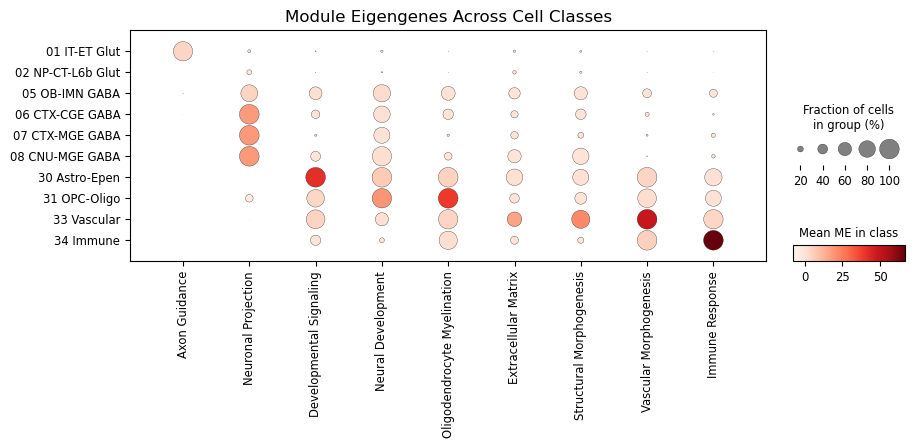

In [10]:
# Convert to AnnData (required for scanpy plotting)
adata_vis = sc.AnnData(eigengenes)
adata_vis.obs["class"] = adata.obs["class"]  # Add cell type labels

# Matrixplot
sc.pl.dotplot(
    adata_vis,
    var_names=custom_module_order,
    groupby="class",
    swap_axes=False,  # Show modules on y-axis, cell types on x-axis
    figsize=(10, 3),  # Adjust size as needed
    title="Module Eigengenes Across Cell Classes",
    colorbar_title="Mean ME in class",
    # cmap="viridis",  # Color map
    dendrogram=False,  # Disable clustering for simplicity
    use_raw=False,
    save = "Isocortex_CNA.svg"
)

In [18]:
# Adding MEs to AnnData object
merged_df = pd.merge(adata.obs, eigengenes, left_index=True, right_index=True)
merged_df.head()

,cell_barcode,barcoded_cell_sample_label,library_label,feature_matrix_label,entity,brain_section_label,library_method,region_of_interest_acronym,donor_label,donor_genotype,...,region_of_interest_color,Axon Guidance,Developmental Signaling,Extracellular Matrix,Immune Response,Neural Development,Neuronal Projection,Oligodendrocyte Myelination,Structural Morphogenesis,Vascular Morphogenesis
cell_label,,,,,,,,,,,,,,,,,,,,,
GCACTAAGTACAAGTA-399_B02,GCACTAAGTACAAGTA,399_B02,L8TX_201022_01_H06,WMB-10Xv3-Isocortex-1,cell,NaN,10Xv3,RSP,Snap25-IRES2-Cre;Ai14-546810,Snap25-IRES2-Cre/wt;Ai14(RCL-tdT)/wt,...,#E4FF26,2.958812,-0.792568,0.528352,-1.038982,-0.592255,-0.758558,-1.228514,-0.238945,-1.165658
CAGAGCCGTCCTGGTG-399_A02,CAGAGCCGTCCTGGTG,399_A02,L8TX_201023_01_A09,WMB-10Xv3-Isocortex-1,cell,NaN,10Xv3,RSP,Snap25-IRES2-Cre;Ai14-546810,Snap25-IRES2-Cre/wt;Ai14(RCL-tdT)/wt,...,#E4FF26,2.600224,-2.073552,-0.469465,-1.508286,-1.140003,-1.729488,-1.837307,-0.232849,-1.746566
CGCCATTCACGACAGA-403_A06,CGCCATTCACGACAGA,403_A06,L8TX_201022_01_B07,WMB-10Xv3-Isocortex-1,cell,NaN,10Xv3,RSP,Snap25-IRES2-Cre;Ai14-547057,Snap25-IRES2-Cre/wt;Ai14(RCL-tdT)/wt,...,#E4FF26,1.865214,-2.334886,-0.463058,-1.079665,-1.116549,0.336061,-2.047574,-0.688967,-1.371987
GGGTTTATCCGATCGG-399_B02,GGGTTTATCCGATCGG,399_B02,L8TX_201022_01_H06,WMB-10Xv3-Isocortex-1,cell,NaN,10Xv3,RSP,Snap25-IRES2-Cre;Ai14-546810,Snap25-IRES2-Cre/wt;Ai14(RCL-tdT)/wt,...,#E4FF26,1.836583,-2.136351,-0.185522,-1.104986,-1.326958,-0.770627,-1.390435,-0.292726,-1.165365
GTGTGATCAGACAAAT-399_B02,GTGTGATCAGACAAAT,399_B02,L8TX_201022_01_H06,WMB-10Xv3-Isocortex-1,cell,NaN,10Xv3,RSP,Snap25-IRES2-Cre;Ai14-546810,Snap25-IRES2-Cre/wt;Ai14(RCL-tdT)/wt,...,#E4FF26,3.115028,-1.995385,-0.557122,-0.647994,-1.145523,-2.775715,-1.306925,-0.239403,-1.162334


In [33]:
def plot_multiple_umaps(data, modules, x_col="x", y_col="y", fig_width=4, fig_height=4, cmap="viridis"):
    """
    Plots multiple UMAP visualizations for the specified modules.

    Parameters:
        data (pd.DataFrame): The dataframe containing UMAP coordinates and the module eigengenes.
        modules (list): List of module names to plot.
        x_col (str): Column name for the x-axis UMAP coordinate.
        y_col (str): Column name for the y-axis UMAP coordinate.
        fig_width (float): Width of each subplot.
        fig_height (float): Height of each subplot.
        cmap (str): Colormap for the scatter plots.

    Returns:
        None
    """
    n_cols = 4  # Number of columns for subplots
    n_rows = math.ceil(len(modules) / n_cols)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(fig_width * n_cols, fig_height * n_rows))
    axes = axes.flatten()

    for i, module in enumerate(modules):
        ax = axes[i]
        scatter = ax.scatter(
            data[x_col],
            data[y_col],
            s=0.5,
            c=data[module],
            cmap=cmap,
            marker='.',
            edgecolor='none'
        )

        ax.axis('equal')
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_title(f"\"{module}\" module")

        fig.colorbar(scatter, ax=ax, orientation='vertical', label="ME expression")

    # Turn off unused subplots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

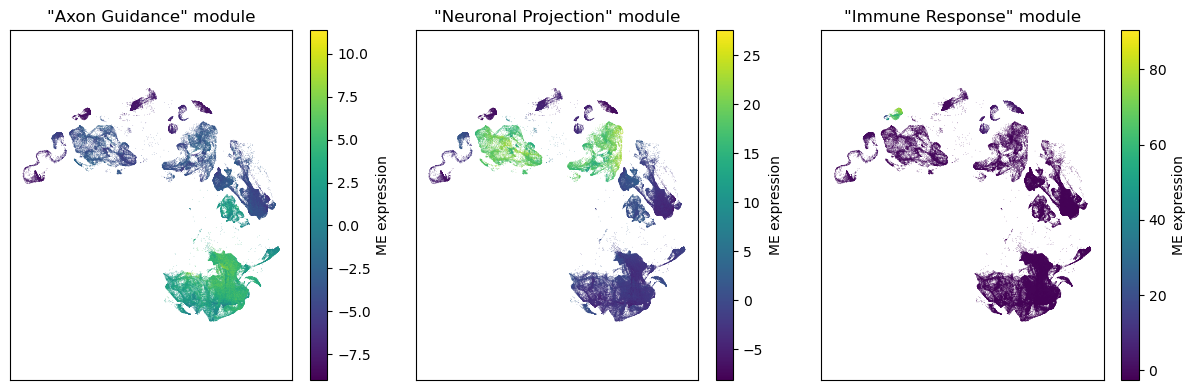

In [35]:
# select_modules = ["Immune Response", "Oligodendrocyte Myelination", "Developmental Signaling", "Neuronal Projection"]
select_modules = ["Axon Guidance", "Neuronal Projection", "Immune Response"]
plot_multiple_umaps(merged_df, select_modules)

In [36]:
tau_scores = {}

for module in select_modules:
    tau_df = merged_df[["class", module]].copy()
    tau_df[module] = tau_df[module] - tau_df[module].min() + 1e-6  # Shift the eigengene values to ensure non-negativity

    # Compute average eigengene per cell class
    avg_expression = tau_df.groupby('class', observed=False)[module].mean()

    # Normalize by the maximum average expression
    max_expr = avg_expression.max()
    normalized_expr = avg_expression / max_expr

    # Compute tau score
    tau = np.sum(1 - normalized_expr) / (len(normalized_expr) - 1)
    tau_scores[module] = tau

# Print Tau scores for all modules
for module, score in tau_scores.items():
    print(f"Tau specificity score for {module} module: {score:.3f}")

Tau specificity score for Axon Guidance module: 0.721
Tau specificity score for Neuronal Projection module: 0.621
Tau specificity score for Immune Response module: 0.962


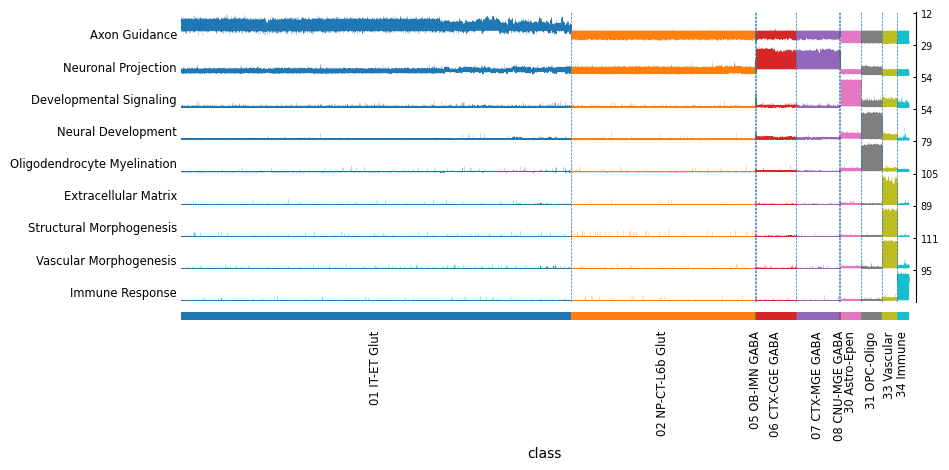

In [38]:
# Add all module eigengenes to AnnData and class labels
all_modules = [col for col in merged_df.columns if col in module_gene_dict.keys()]
adata_tracks = sc.AnnData(merged_df[all_modules])
adata_tracks.obs["class"] = merged_df["class"].astype("category")  # Ensure categorical dtype

# Plot tracksplot of module eigengenes across cell classes
sc.pl.tracksplot(
    adata_tracks,
    var_names=custom_module_order,
    groupby="class",
    figsize=(10, 4),
    dendrogram=False,
    title="Tracksplot of Module Eigengenes Across Cell Classes",
    # cmap="viridis"
)

In [39]:
n_top_genes_per_module = 2  # Set the number of top genes to select per module

# Create an empty list to store dataframes for each module
top_genes_by_module = []

# Iterate through each unique module in the "module" column
for module_name in modules_df["module"].unique():
    # Filter the dataframe for the current module
    module_genes = modules_df[modules_df["module"] == module_name]
    
    # Sort the genes by the corresponding kME column in descending order
    sorted_genes = module_genes.sort_values(by=f"kME_{module_name}", ascending=False)
    
    # Select the top genes (you can adjust the number of top genes as needed)
    top_genes = sorted_genes.head(n_top_genes_per_module)
    
    # Append the top genes dataframe to the list
    top_genes_by_module.append(top_genes)

# Combine all the top genes dataframes into a single dataframe
top_genes_df = pd.concat(top_genes_by_module, ignore_index=True)

# Display the resulting dataframe
top_genes_df.head()

,gene_name,module,color,kME_Isocortex-M1,kME_Isocortex-M2,kME_Isocortex-M3,kME_Isocortex-M4,kME_grey,kME_Isocortex-M5,kME_Isocortex-M6,kME_Isocortex-M7,kME_Isocortex-M8,kME_Isocortex-M9
0,ENSMUSG00000033579,Isocortex-M1,yellow,0.931046,-0.094431,0.014312,0.035500,-0.096881,0.045765,0.305594,0.001473,0.003802,-0.213210
1,ENSMUSG00000037625,Isocortex-M1,yellow,0.926951,-0.103769,0.018537,0.047911,-0.095544,0.037631,0.131973,0.026364,0.068962,-0.209419
2,ENSMUSG00000026787,Isocortex-M2,turquoise,-0.011908,0.913981,-0.012700,-0.016992,-0.158939,-0.021097,0.069336,0.004123,-0.000682,-0.266210
3,ENSMUSG00000037771,Isocortex-M2,turquoise,-0.016164,0.903847,-0.018195,-0.022709,-0.157596,-0.028394,0.060217,-0.002996,-0.001836,-0.259361
4,ENSMUSG00000024621,Isocortex-M3,blue,0.032446,-0.113386,0.967422,0.084476,-0.085543,0.008932,-0.022843,-0.010405,-0.004951,-0.200912


In [40]:
gene_names_df = adata.var.copy()

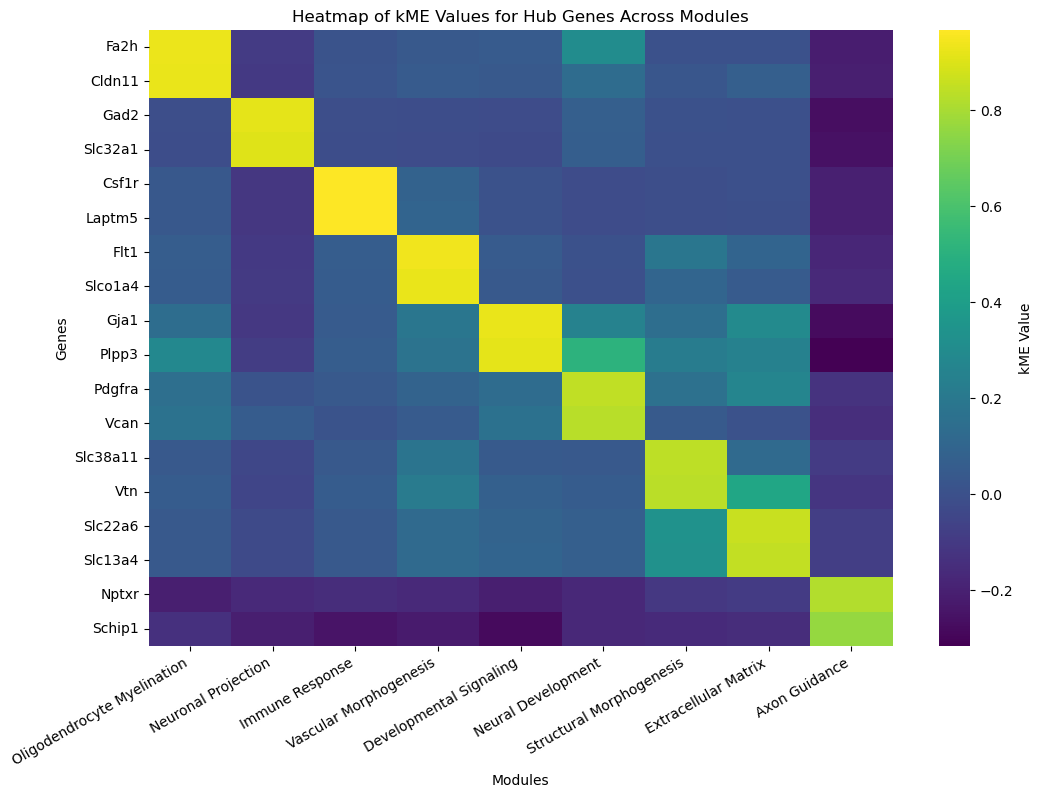

In [48]:
# Map gene IDs to gene symbols
gene_symbol_mapping = gene_names_df["gene_symbol"].to_dict()
top_genes_df["gene_symbol"] = top_genes_df["gene_name"].map(gene_symbol_mapping)

# Prepare the data for the heatmap
heatmap_data = top_genes_df.set_index("gene_symbol")[[f"kME_{module}" for module in top_genes_df["module"].unique()]]
heatmap_data.columns = [
    module_names.get(col.replace("kME_", ""), col.replace("kME_", ""))
    for col in heatmap_data.columns
]

# Create the heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(
    heatmap_data,
    cmap="viridis",
    annot=False,
    cbar_kws={"label": "kME Value"}
)

# Set axis labels and title
plt.xticks(rotation=30, ha="right")
plt.xlabel("Modules")
plt.ylabel("Genes")
plt.title("Heatmap of kME Values for Hub Genes Across Modules")
plt.savefig("figures/heatmap_kME_Isoctx.svg")
plt.show()

### Overlap with DEGs

In [7]:
# Loading the DEG dataframe
group_by = "class"
base_path = Path("/data/scRNA/ABCA/AIBS/AWS/expression_matrices/WMB-10Xv3/20230630/")
deg_path = base_path / "outputs/DEG/" / f"WMB-10Xv3-{select_region}-DEG-{group_by}.csv"
deg_results = pd.read_csv(deg_path)
deg_results.head(3)

,01 IT-ET Glut,02 NP-CT-L6b Glut,05 OB-IMN GABA,06 CTX-CGE GABA,07 CTX-MGE GABA,08 CNU-MGE GABA,30 Astro-Epen,31 OPC-Oligo,33 Vascular,34 Immune
0,C1ql3,Hs3st4,H3f3b,Adarb2,Kcnc2,Sox2ot,Plpp3,Olig1,Sparc,Laptm5
1,Cck,Cdh18,Zbtb20,Dlx6os1,Rab3b,Alk,Slc1a3,Qk,Utrn,Inpp5d
2,Tafa1,Foxp2,Msi2,Gad1,Slc32a1,Nkain3,Slc1a2,Gjc3,Zbtb20,Cst3


In [10]:
# 1. Get top 100 DEGs per class from deg_results (each column is a class, values are gene names)
top_n_deg = 100
deg_sets = {
    cls: set(deg_results[cls].dropna().head(top_n_deg))
    for cls in deg_results.columns
}

# 2. Build module gene sets (using gene symbols)
gene_symbol_map = adata.var["gene_symbol"].to_dict()
module_gene_sets = {
    mod: set([gene_symbol_map.get(g, g) for g in genes if gene_symbol_map.get(g, g) is not None])
    for mod, genes in module_gene_dict.items()
}

# 3. Compute Jaccard index matrix
import pandas as pd
jaccard_matrix = pd.DataFrame(
    index=module_gene_sets.keys(),
    columns=deg_sets.keys(),
    dtype=float
)

for mod, mod_genes in module_gene_sets.items():
    for cls, deg_genes in deg_sets.items():
        intersection = len(mod_genes & deg_genes)
        union = len(mod_genes | deg_genes)
        jaccard = intersection / union if union > 0 else 0.0
        jaccard_matrix.loc[mod, cls] = jaccard

# 4. Plot heatmap
plt.figure(figsize=(8, 8))
sns.heatmap(
    jaccard_matrix.astype(float).T,
    annot=False,
    fmt=".2f",
    cmap="Blues",
    cbar_kws={"label": "Jaccard Index"}
)
plt.title("Jaccard Index between Module Genes and Top 100 DEGs per Class")
plt.xlabel("Module")
plt.ylabel("Cell Class")
plt.tight_layout()
# plt.savefig("figures/heatmap_jaccard_index_Isoctx_CNA.svg")
plt.show()

NameError: name 'module_gene_dict' is not defined

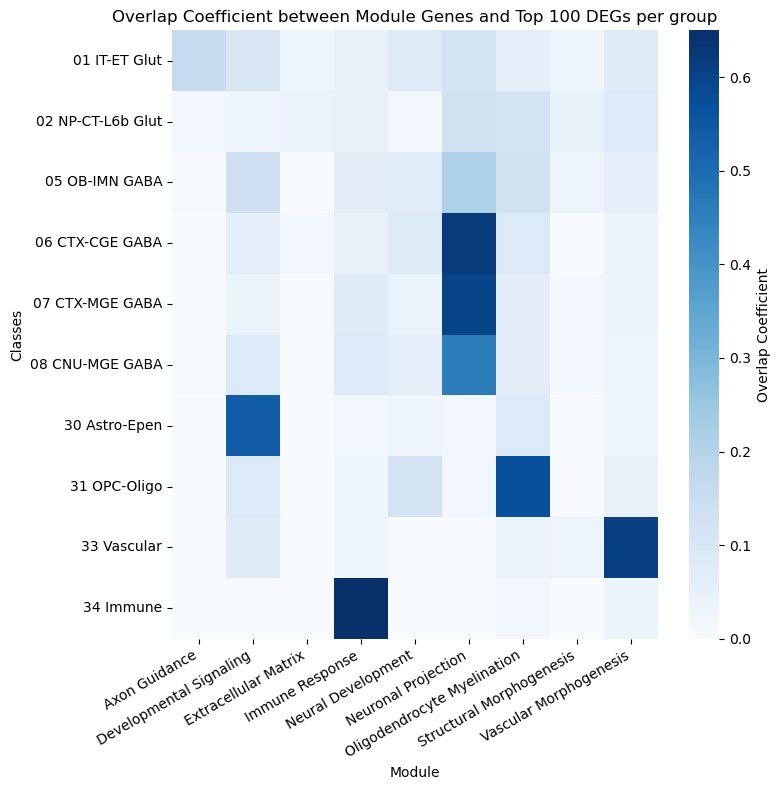

In [16]:
# 1. Get top 100 DEGs per class from deg_results (each column is a class, values are gene names)
top_n_deg = 100
deg_sets = {
    cls: set(deg_results[cls].dropna().head(top_n_deg))
    for cls in deg_results.columns
}

# Get unique modules and their gene lists
module_gene_dict = modules_df_renamed.groupby("module")["gene_name"].apply(list).to_dict()

# 2. Build module gene sets (using gene symbols)
gene_symbol_map = adata.var["gene_symbol"].to_dict()
module_gene_sets = {
    mod: set([gene_symbol_map.get(g, g) for g in genes if gene_symbol_map.get(g, g) is not None])
    for mod, genes in module_gene_dict.items()
}

# 3. Compute Overlap Coefficient matrix (Szymkiewicz–Simpson)
import pandas as pd
import numpy as np

overlap_matrix = pd.DataFrame(
    index=module_gene_sets.keys(),
    columns=deg_sets.keys(),
    dtype=float
)

for mod, mod_genes in module_gene_sets.items():
    for cls, deg_genes in deg_sets.items():
        inter = len(mod_genes & deg_genes)
        denom = min(len(mod_genes), len(deg_genes))
        overlap = inter / denom if denom > 0 else np.nan  # avoid divide-by-zero
        overlap_matrix.loc[mod, cls] = overlap

# 4. Plot heatmap
plt.figure(figsize=(8, 8))
sns.heatmap(
    overlap_matrix.astype(float).T,
    annot=False,
    fmt=".2f",
    cmap="Blues",
    cbar_kws={"label": "Overlap Coefficient"}
)
plt.title(f"Overlap Coefficient between Module Genes and Top {top_n_deg} DEGs per group")
plt.xlabel("Module")
plt.xticks(rotation=30, ha="right")
plt.ylabel("Classes")
plt.tight_layout()
# plt.savefig("figures/heatmap_overlap_coefficient_Super_CNA.svg")
plt.show()
